In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted

from kbkit.io import RdfParser
from kbkit.kbi import KBIConvergenceError, KBIntegrator
from kbkit.systems import SystemProperties

In [ ]:
# get the system for each box length (nm)
size_to_system = {
    3.2: "sys_704",
    4: "sys_706",
    6: "sys_701",
    8: "sys_705",  # sys_702
    10: "sys_406",
}


def get_syspath(boxsize):
    """Get path to system directory."""
    return Path(f"./test_data/size_effects/{size_to_system[boxsize]}")

In [ ]:
# create objects for each system/rdf combo


def update_integrators(boxlength, time, int_objs):
    """Add integrator object for Boxlength and Time to int_objs."""
    syspath = get_syspath(boxlength)
    rdf_path = next(syspath.glob(f"*rdf*_{time}ns"))
    files = natsorted(rdf_path.glob("*.xvg"))
    new_ints = {}
    for f in files:
        rdf = RdfParser(path=f)
        integ = KBIntegrator.from_system_properties(rdf=rdf, system_properties=SystemProperties(f.parent.parent))
        new_ints[tuple(integ.rdf_molecules)] = integ
    int_objs[boxlength][time] = new_ints
    return int_objs


boxlengths = list(size_to_system.keys())
times = set()
integrators = {b: {} for b in boxlengths}
mol_pairs = set()

for b in size_to_system:
    syspath = get_syspath(b)

    rdf_paths = natsorted(syspath.glob("*rdf*ns*"))
    times_str = [int(str(f.name).split("_")[-1].strip("ns")) for f in rdf_paths]

    for time in times_str:
        times.add(int(time))  # update times
        integrators = update_integrators(boxlength=b, time=time, int_objs=integrators)
        for mols in integrators[b][time]:
            mol_pairs.add(mols)

In [4]:
mol_pairs = natsorted(mol_pairs)
times = natsorted(times)

min_r_range = 1.0
r2_threshold = 0.9999

results = {mols: {b: {} for b in integrators} for mols in mol_pairs}
kbis = np.full((3, len(integrators), len(times)), fill_value=np.nan)
kbis_forced = np.full((3, len(integrators), len(times)), fill_value=np.nan)

for b, (boxlength, b_dict) in enumerate(integrators.items()):
    for t, (time, t_dict) in enumerate(b_dict.items()):
        for mols, integrator in t_dict.items():
            i = list(mol_pairs).index(mols)
            try:
                kbi_res = integrator.fit_running_kbi(min_r_range=min_r_range, r2_threshold=r2_threshold, force=False)
                kbi_res.update(
                    {
                        "x": integrator.r,
                        "y": integrator.r * integrator.running_kbi(),
                        "gr": integrator.g_vdv(),
                    }
                )

                results[mols][boxlength][time] = kbi_res
                kbis[i, b, t] = kbi_res["slope"]
                kbis_forced[i, b, t] = kbi_res["slope"]

            except KBIConvergenceError:
                kbi_res = integrator.fit_running_kbi(min_r_range=min_r_range, r2_threshold=r2_threshold, force=True)
                kbi_res.update(
                    {
                        "x": integrator.r,
                        "y": integrator.r * integrator.running_kbi(),
                        "gr": integrator.g_vdv(),
                    }
                )
                results[mols][boxlength][time] = kbi_res
                kbis_forced[i, b, t] = kbi_res["slope"]

                print(
                    f"KBIConvergenceError: Convergence failed for {boxlength=}nm, {time=}ns, and molecules='{'-'.join(integrator.rdf_molecules)}'"
                )

KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=10ns, and molecules='ETHOL-ETHOL'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=10ns, and molecules='ETHOL-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=10ns, and molecules='SPCEW-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=50ns, and molecules='ETHOL-ETHOL'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=50ns, and molecules='ETHOL-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=50ns, and molecules='SPCEW-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=100ns, and molecules='ETHOL-ETHOL'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=100ns, and molecules='ETHOL-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=100ns, and molecules='SPCEW-SPCEW'
KBIConvergenceError: Convergence failed for boxlength=3.2nm, time=150ns, and molecules='ETHOL-ETH

In [ ]:
### kbi plotting fns


def plot_many_kbi_single_boxlength(boxlength: int, show_forced: bool = True, rdf_ylim=None):
    """Plot KBI results for all mol-pairs at a given boxlength."""
    fig, ax = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
    fig.suptitle(f"KBI Analysis for Boxlength: {boxlength}nm", fontsize=18)
    colors = plt.cm.rainbow(np.linspace(0, 1, 5))

    for mols, res in results.items():
        i = list(mol_pairs).index(mols)
        box_res = res[boxlength]
        b = list(size_to_system.keys()).index(boxlength)
        for t, (time, t_res) in enumerate(box_res.items()):
            if not t_res:
                continue
            ax[i, 0].plot(t_res["x"], t_res["gr"], lw=1.5, alpha=0.7, color=colors[t], label=f"{time} ns")
            if rdf_ylim:
                ax[i, 0].set_ylim(rdf_ylim)
            # ax[i,0].set_xlim(0.5,t_res['x'].max())

            ax[i, 1].plot(t_res["x"], t_res["y"] / t_res["x"], lw=1.5, alpha=0.8, color=colors[t], label=f"{time} ns")
            ax[i, 1].legend(fontsize=12)

            ax[i, 2].plot(t_res["x"], t_res["y"], lw=1.5, alpha=0.5, color=colors[t])

            if not show_forced and np.isnan(kbis[i, b, t]):
                continue
            ax[i, 2].plot(
                t_res["x_fit"],
                t_res["x_fit"] * t_res["slope"] + t_res["intercept"],
                lw=2.5,
                alpha=1,
                color=colors[t],
                ls="--",
                label=rf"$G_{{ij}}^\infty$({time}ns)={t_res['slope']:.4f}",
            )
        ax[i, 2].legend()
        ax[i, 0].set_ylabel(r"g$_{ij}^{vdV}$(r)")
        ax[i, 1].set_ylabel(r"$G_{ij}^R$ [nm$^3$]")
        ax[i, 2].set_ylabel(r"$R \times G_{ij}^R$ [nm$^4$]")
        ax[2, i].set_xlabel("R [nm]")
    fig.text(0.16, 0.69, "-".join(mol_pairs[0]), fontfamily="Arial", fontsize=16)
    fig.text(0.16, 0.38, "-".join(mol_pairs[1]), fontfamily="Arial", fontsize=16)
    fig.text(0.16, 0.07, "-".join(mol_pairs[2]), fontfamily="Arial", fontsize=16)
    plt.show()


def plot_single_kbi_single_boxlength(mol_pair: tuple, boxlength: int, show_forced: bool = True, rdf_ylim=None):
    """Plot kbi results for 1 mol-pair at 1 boxlength."""
    mol_pair = tuple([mol.upper() for mol in mol_pair])
    fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    fig.suptitle(f"KBI Analysis for Molecules: {'-'.join(mol_pair)}, Boxlength: {boxlength}nm", fontsize=18)
    colors = plt.cm.rainbow(np.linspace(0, 1, 5))

    mol_res = results[mol_pair]
    i = list(mol_pairs).index(mol_pair)
    box_res = mol_res[boxlength]
    b = list(boxlengths).index(boxlength)

    for t, (time, t_res) in enumerate(box_res.items()):
        if not t_res:
            continue
        ax[0].plot(t_res["x"], t_res["gr"], lw=1.5, alpha=0.7, color=colors[t], label=f"{time} ns")
        if rdf_ylim:
            ax[0].set_ylim(rdf_ylim)

        ax[1].plot(t_res["x"], t_res["y"] / t_res["x"], lw=1.5, alpha=0.8, color=colors[t], label=f"{time} ns")
        ax[1].legend(fontsize=12, ncol=1, loc="best")

        ax[2].plot(t_res["x"], t_res["y"], lw=1.5, alpha=0.5, color=colors[t])

        if not show_forced and np.isnan(kbis[i, b, t]):
            continue
        ax[2].plot(
            t_res["x_fit"],
            t_res["x_fit"] * t_res["slope"] + t_res["intercept"],
            lw=2.5,
            alpha=1,
            color=colors[t],
            ls="--",
            label=rf"$G_{{ij}}^\infty$({time}ns)={t_res['slope']:.4f}",
        )
    ax[2].legend()
    ax[0].set_ylabel(r"g$_{ij}^{vdV}$(r)")
    ax[1].set_ylabel(r"$G_{ij}^R$ [nm$^3$]")
    ax[2].set_ylabel(r"$R \times G_{ij}^R$ [nm$^4$]")
    for jj in range(3):
        ax[jj].set_xlabel("R [nm]")
    plt.show()


def plot_single_kbi_vs_boxsize(mol_pair: tuple, show_forced: bool = False, rdf_ylim=None):
    """Plot KBI results for 1 mol-pair over all box lengths."""
    mol_pair = tuple([mol.upper() for mol in mol_pair])
    fig, ax = plt.subplots(len(boxlengths), 3, figsize=(12, 15), sharex=True)
    fig.suptitle(f"KBI Box Size Effects for Molecules: {'-'.join(mol_pair)}", fontsize=18)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(boxlengths)))

    mol_res = results[mol_pair]
    i = list(mol_pairs).index(mol_pair)

    for b, (boxlength, box_res) in enumerate(mol_res.items()):
        for t, (time, t_res) in enumerate(box_res.items()):
            if not t_res:
                continue
            ax[b, 0].plot(t_res["x"], t_res["gr"], lw=1.5, alpha=0.7, color=colors[t], label=f"{time} ns")
            if rdf_ylim:
                ax[b, 0].set_ylim(rdf_ylim)

            ax[b, 1].plot(t_res["x"], t_res["y"] / t_res["x"], lw=1.5, alpha=0.8, color=colors[t], label=f"{time} ns")
            ax[b, 1].legend(fontsize=11, ncol=2, loc="lower right", title=f"boxlength={float(boxlength)}nm")

            ax[b, 2].plot(t_res["x"], t_res["y"], lw=1.5, alpha=0.5, color=colors[t])

            if not show_forced and np.isnan(kbis[i, b, t]):
                continue
            ax[b, 2].plot(
                t_res["x_fit"],
                t_res["x_fit"] * t_res["slope"] + t_res["intercept"],
                lw=2.5,
                alpha=1,
                color=colors[t],
                ls="--",
                label=rf"$G_{{ij}}^\infty$({time}ns)={t_res['slope']:.4f}",
            )
        ax[b, 2].legend()
        ax[b, 0].set_ylabel(r"g$_{ij}^{vdV}$(r)")
        ax[b, 1].set_ylabel(r"$G_{ij}^R$ [nm$^3$]")
        ax[b, 2].set_ylabel(r"$R \times G_{ij}^R$ [nm$^4$]")
    for jj in range(3):
        ax[len(boxlengths) - 1, jj].set_xlabel("R [nm]")
    plt.show()

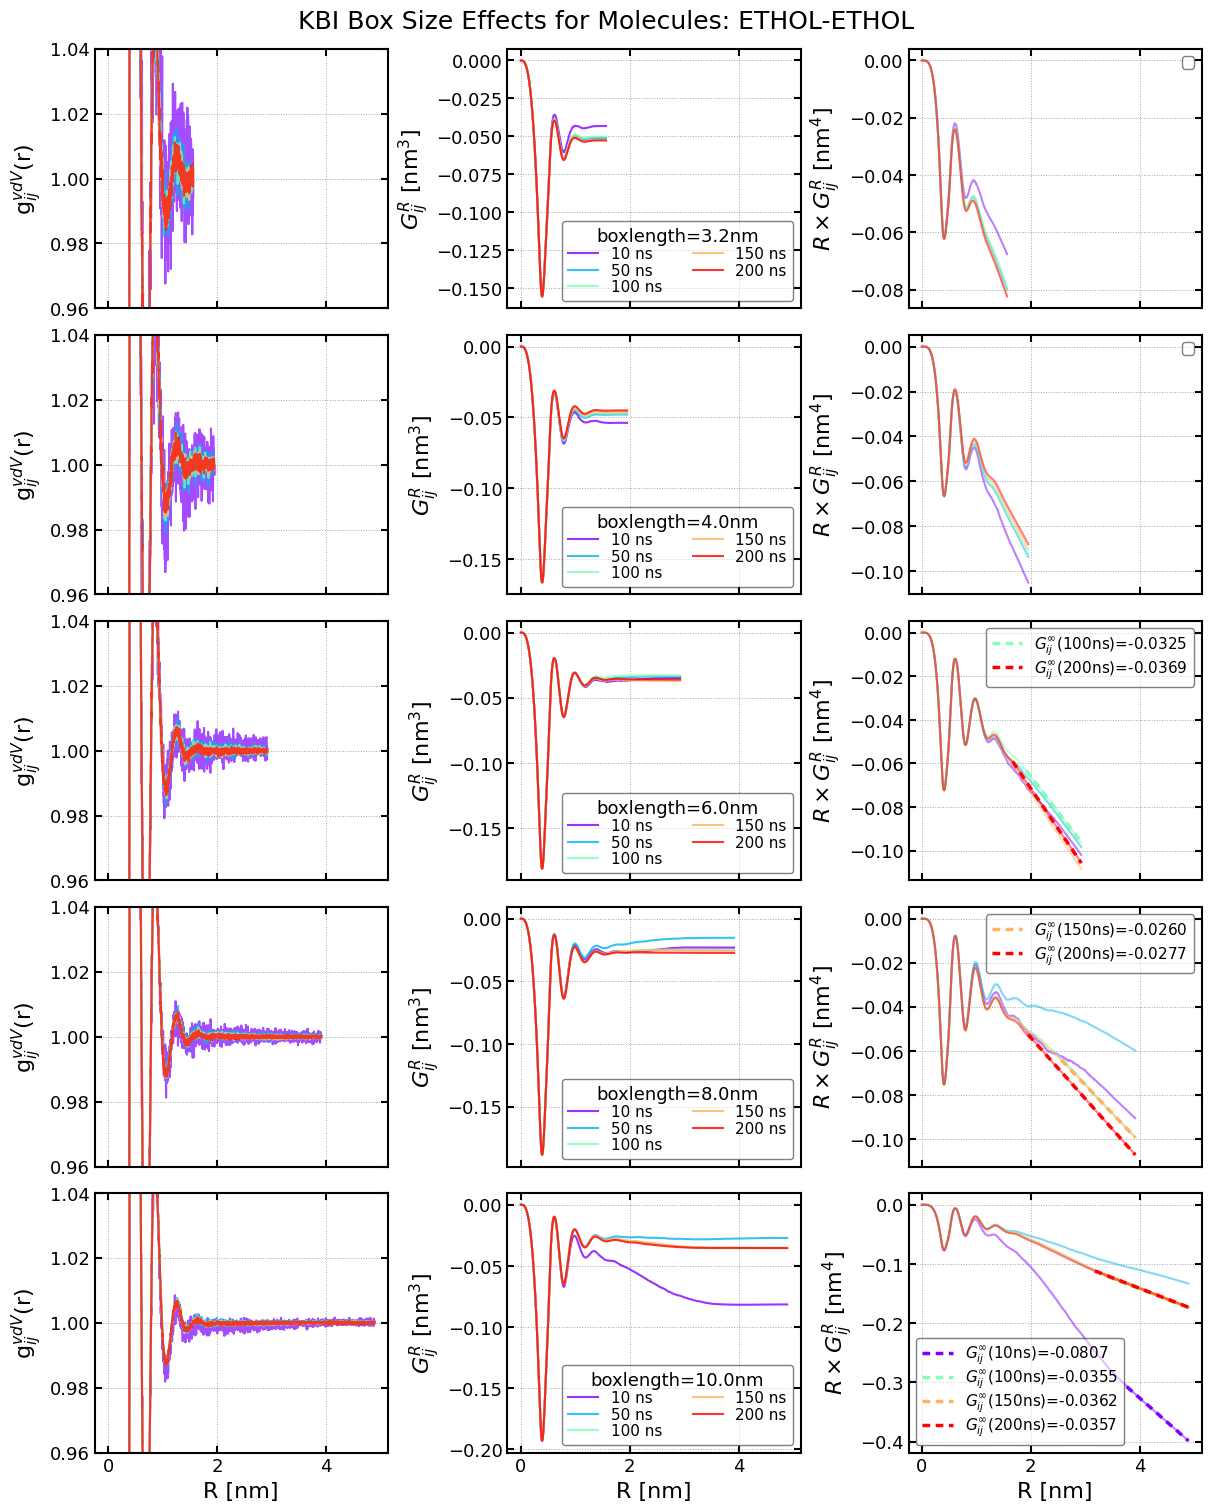

In [6]:
plot_single_kbi_vs_boxsize(mol_pair=mol_pairs[0], rdf_ylim=(0.96, 1.04))

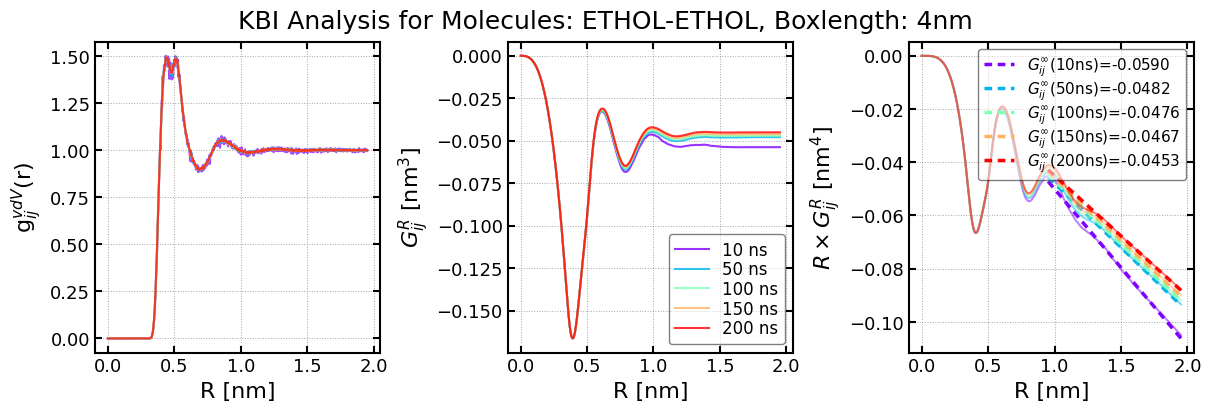

In [7]:
plot_single_kbi_single_boxlength(mol_pair=("ETHOL", "ETHOL"), boxlength=4)

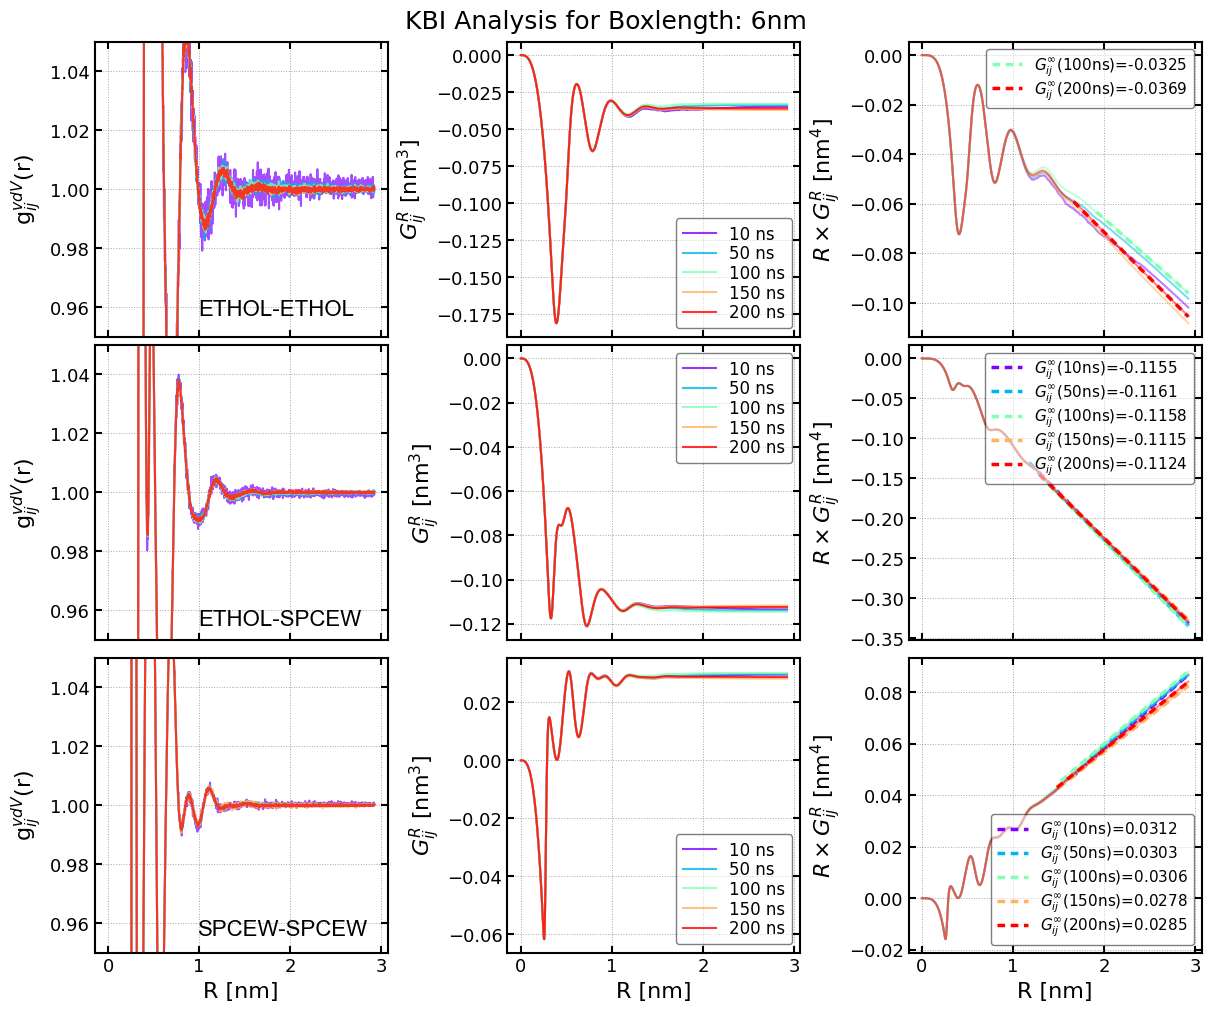

In [8]:
plot_many_kbi_single_boxlength(6, show_forced=False, rdf_ylim=(0.95, 1.05))

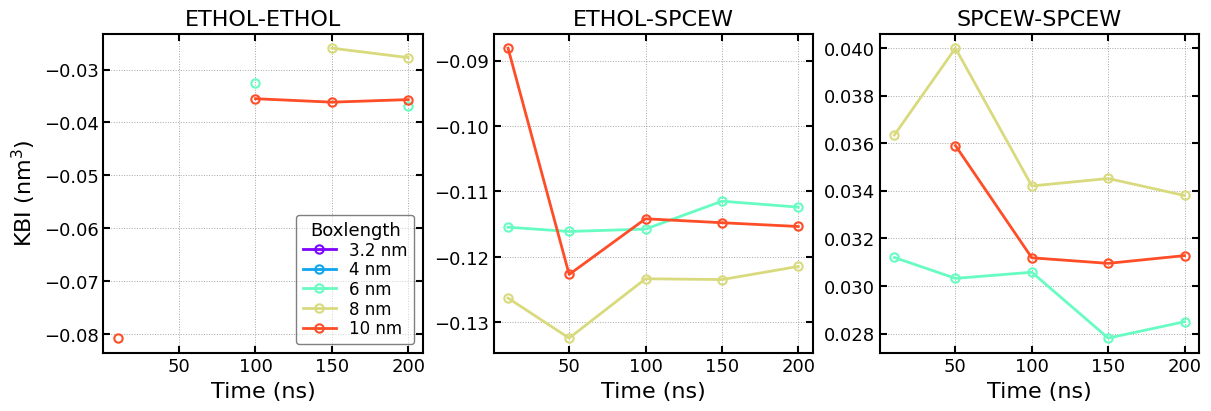

In [9]:
colors = plt.cm.rainbow(np.linspace(0, 0.9, len(size_to_system)))

kbi_plot = kbis  # kbis, kbis_forced
times_sort = natsorted(times)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for b, boxlength in enumerate(boxlengths):
    axes[0].plot(times_sort, kbi_plot[0, b, :], marker="o", ls="-", color=colors[b], label=f"{boxlength} nm")
    axes[1].plot(times_sort, kbi_plot[1, b, :], marker="o", ls="-", color=colors[b], label=f"{boxlength} nm")
    axes[2].plot(times_sort, kbi_plot[2, b, :], marker="o", ls="-", color=colors[b], label=f"{boxlength} nm")


axes[0].set_ylabel(r"KBI (nm$^3$)")
axes[0].legend(fontsize=12, title="Boxlength", ncol=1)

for i in range(len(mol_pairs)):
    axes[i].set_xlabel("Time (ns)")
    axes[i].set_title(f"{'-'.join(list(mol_pairs)[i])}")


plt.show()

In [ ]:
### plotting functions

from typing import Literal

import matplotlib as mpl
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from scipy.interpolate import griddata


def plot_contour(
    kbi_type: Literal["value", "percent"] = "value",
    forced: bool = False,
    absolute: bool = False,
    abs_max: float = 50,
    show_pts: bool = False,
    levels: int = 20,
    alpha: float = 0.8,
    cmap: str = "jet",
):
    """Make contour plot."""
    kbi1 = kbis if not forced else kbis_forced
    if kbi_type == "value":
        kbi_plot = np.abs(kbi1) if absolute else kbi1
    else:
        kbi_perc_dev = 100 * (kbi1 - kbi1[:, -1, -1][:, None, None]) / kbi1[:, -1, -1][:, None, None]
        kbi_plot = np.abs(kbi_perc_dev) if absolute else kbi_perc_dev

    cmap = mpl.colormaps[cmap]

    # Create meshgrid for plotting
    times_numeric = np.array([float(t) for t in times])

    # Handle categorical boxlengths - create numeric positions for y-axis
    boxlengths_list = list(size_to_system.keys())  # ["3.2", "4", "6", "8a", "8b", "10"]
    y_positions = np.arange(len(boxlengths_list))  # [0, 1, 2, 3, 4, 5]

    # For interpolation, we need numeric values - map to positions
    # Fine grid for interpolation
    times_fine = np.linspace(times_numeric.min(), times_numeric.max(), 200)
    y_fine = np.linspace(y_positions.min(), y_positions.max(), 200)
    T_fine, Y_fine = np.meshgrid(times_fine, y_fine)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, title in enumerate(mol_pairs):
        kbi_min = np.nanmin(kbi_plot[i])
        kbi_max = np.nanmax(kbi_plot[i])
        if kbi_type == "value":
            norm = Normalize(vmin=0 if absolute else kbi_min, vmax=kbi_max)
        elif absolute:
            norm = Normalize(vmin=0, vmax=abs_max)
        else:
            norm = TwoSlopeNorm(vmin=kbi_min, vcenter=0, vmax=kbi_max)

        # Vectorized extraction of valid points
        b_idx, t_idx = np.meshgrid(range(len(boxlengths_list)), range(len(times)), indexing="ij")
        valid_mask = ~np.isnan(kbi_plot[i])

        time_vals = times_numeric[t_idx[valid_mask]]
        y_vals = y_positions[b_idx[valid_mask]]  # Use numeric positions, not strings
        color_vals = kbi_plot[i][valid_mask]

        # Interpolate scattered points onto fine grid for contour plotting
        Z = griddata(
            points=(time_vals, y_vals),  # known (x, y) locations (y is now numeric)
            values=color_vals,  # known KBI values
            xi=(T_fine, Y_fine),  # grid to interpolate onto
            method="cubic",
        )

        # Filled contour plot
        contourf = axes[i].contourf(
            T_fine,
            Y_fine,
            Z,  # Use Y_fine (numeric positions)
            levels=np.linspace(0, abs_max, levels) if absolute else levels,
            cmap=cmap,
            norm=norm,
            alpha=alpha,
            extend="max" if absolute else "neither",
        )

        if show_pts:
            # Overlay original data points
            axes[i].plot(
                time_vals,
                y_vals,  # y_vals are numeric positions
                fillstyle="full",
                mfc="white",
                mec="black",
                marker="o",
                ms=7,
                mew=1,
                ls="none",
                zorder=100,
            )

        axes[i].set_xlabel("Time (ns)")
        axes[i].set_ylabel("Boxlength")
        axes[i].set_title("-".join(title))

        # Set y-ticks to show the original string labels
        axes[i].set_yticks(y_positions)
        axes[i].set_yticklabels(boxlengths_list)
        # axes[i].set_ylim(y_positions.min() - 0.5, y_positions.max() + 0.5)
        axes[i].set_axisbelow(False)

        # Individual colorbar per subplot
        if absolute:
            cbar = plt.colorbar(contourf, ax=axes[i], orientation="vertical", pad=0.02, extend="max")
            label = "Abs. % Deviation (10nm, 200ns)"
        else:
            cbar = plt.colorbar(contourf, ax=axes[i], orientation="vertical", pad=0.02)
            label = r"KBI (nm$^3$)" if kbi_type == "value" else r"% Deviation (10nm, 200ns)"
        cbar.set_label(label, fontsize=12)
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.show()


def plot_heatmap(forced: bool = False, absolute: bool = False, cmap: str = "coolwarm"):
    """Make heatmap plot."""
    # Create meshgrid for plotting
    times_numeric = np.array([float(t) for t in times])
    boxlengths_array = np.array(list(size_to_system.keys()))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    kbi1 = kbis if not forced else kbis_forced
    kbi_plot = 100 * (kbi1 - kbi1[:, -1, -1][:, None, None]) / kbi1[:, -1, -1][:, None, None]

    for i, title in enumerate(mol_pairs):
        data = kbi_plot[i] if not absolute else np.abs(kbi_plot[i])

        # TwoSlopeNorm anchors vcenter=0 to the middle of the colormap (white)
        # vmin/vmax are set symmetrically so the colorbar is balanced
        abs_max = np.nanmax(np.abs(data))
        if absolute:
            norm = Normalize(vmin=0, vmax=50)
        else:
            norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

        im = axes[i].imshow(
            data,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            norm=norm,  # apply the two-slope norm
            interpolation="nearest",
        )

        # Set tick positions and labels
        axes[i].set_xticks(range(len(times_numeric)))
        axes[i].set_xticklabels(times_numeric)
        axes[i].set_yticks(range(len(boxlengths_array)))
        axes[i].set_yticklabels(boxlengths_array)

        axes[i].set_xlabel("Time (ns)")
        axes[i].set_ylabel("Boxlength (nm)")
        axes[i].set_title("-".join(title))

        # Individual colorbar per subplot
        cbar = plt.colorbar(im, ax=axes[i], orientation="vertical", pad=0.02, extend="max")
        c_lab = "Abs. % Deviation (10nm, 200ns)" if absolute else "% Deviation (10nm, 200ns)"
        cbar.set_label(c_lab, fontsize=12)

        # Annotate each cell with its value
        # Use data value (not raw KBI) to determine text contrast
        for b in range(len(boxlengths_array)):
            for t in range(len(times_numeric)):
                val = data[b, t]
                if not np.isnan(val):
                    axes[i].text(
                        t,
                        b,
                        f"{val:.1f}",
                        ha="center",
                        va="center",
                        fontsize=14,
                        color="black" if abs(val) < 35 else "white",
                    )
    plt.show()

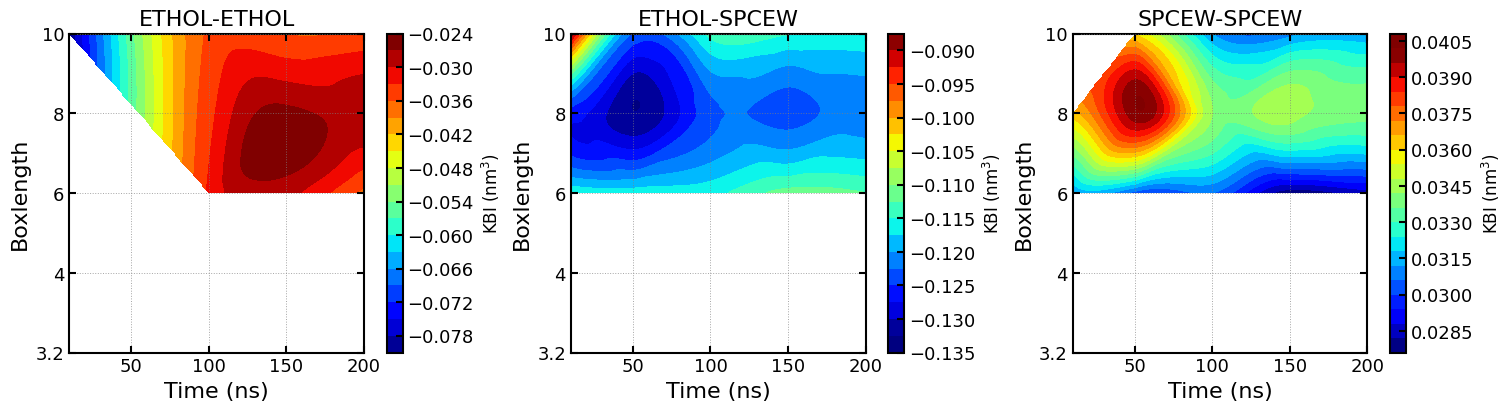

In [11]:
plot_contour("value", forced=False, levels=20, alpha=1, cmap="jet", show_pts=False)

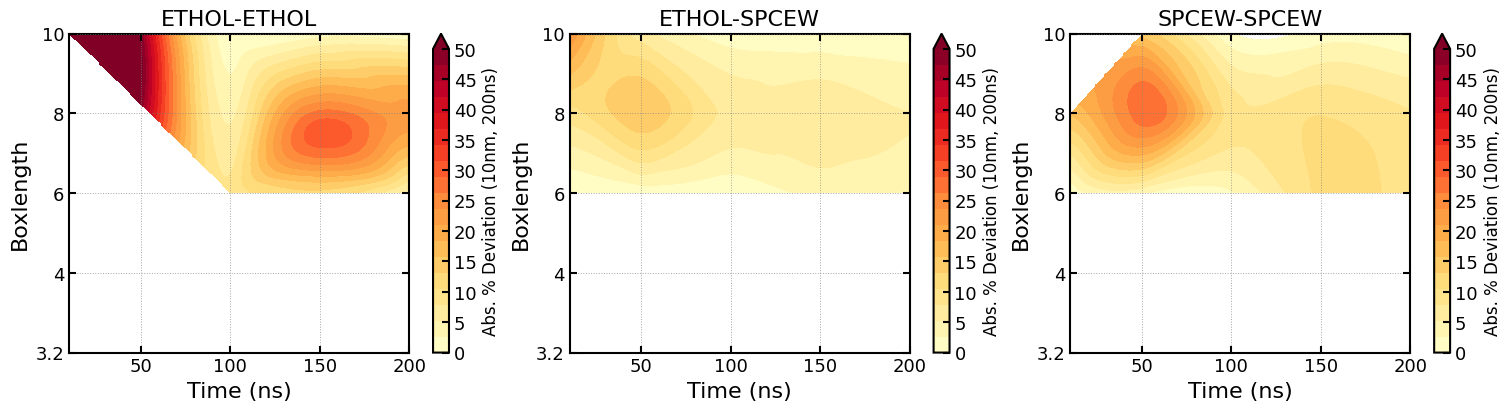

In [12]:
plot_contour("percent", absolute=True, forced=False, levels=20, abs_max=50, alpha=1, cmap="YlOrRd", show_pts=False)

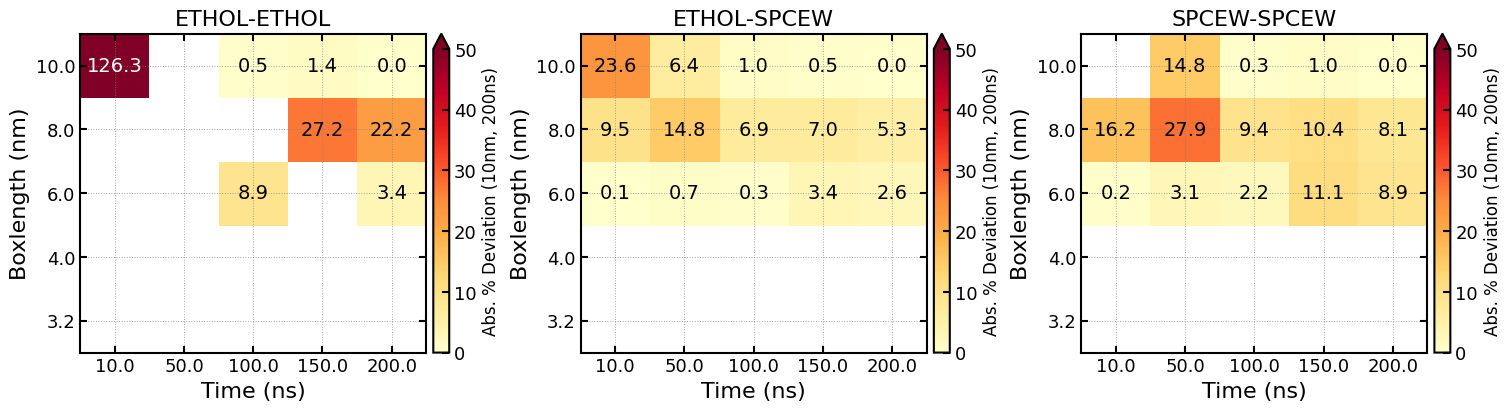

In [13]:
plot_heatmap(absolute=True, forced=False, cmap="YlOrRd")